# 05 — Tag transactions

Tag each sales row with is_promo (promo_cal match), is_markdown (price < threshold × SKU median), is_stockout_week (inv=0 that week OR shipped < customer typical weekly).

**Upstream:** sales_with_brand.parquet, promo_cal.parquet, inv_weekly.parquet

**Output:** sales_tagged.parquet

**Promotes to:** `src/tagging.py` once verified.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
DATA = ROOT / 'data'
ART = ROOT / 'pipeline' / 'artifacts'
ART.mkdir(parents=True, exist_ok=True)

# Sales LOCNCODE -> DC string (matches inv_weekly.DC from step 04)
DC_MAP = {'1': 'SF', '2': 'NJ', '3': 'LA', 1: 'SF', 2: 'NJ', 3: 'LA'}

# Tunable thresholds
MARKDOWN_FACTOR     = 0.70   # Unit_Price_adj < 0.70 * SKU median -> is_markdown
LOST_DEMAND_COVER_K = 1.0    # low_stock if week_on_hand < K * typical weekly base sales
LOST_DEMAND_ORDER_F = 0.70   # cust shorted if order < F * customer median base qty for SKU
LOST_DEMAND_MIN_N   = 3      # min orders per (customer, SKU) to trust the customer median


## 2. Load upstream

In [2]:
sales = pd.read_parquet(ART / 'sales_with_brand.parquet')
promo_cal = pd.read_parquet(ART / 'promo_cal.parquet')
inv_weekly = pd.read_parquet(ART / 'inv_weekly.parquet')

# promo_cal.promo_ym was stringified on save; round-trip back to Period[M].
promo_cal['promo_ym'] = pd.PeriodIndex(promo_cal['promo_ym'], freq='M')

print(f'sales      : {sales.shape}   cols={list(sales.columns)[:8]}...')
print(f'promo_cal  : {promo_cal.shape}')
print(f'inv_weekly : {inv_weekly.shape}  confidence={inv_weekly["confidence"].value_counts().to_dict()}')


sales      : (236818, 24)   cols=['LOCNCODE', 'SLPRSNID', 'CUSTNMBR', 'CITY', 'STATE', 'ZIPCODE', 'SOP TYPE', 'SOPNUMBE']...
promo_cal  : (1391, 3)
inv_weekly : (37887, 5)  confidence={'high': 33043, 'low': 4844}


## 3. Do the work

In [3]:
# ---- Normalize sales keys ---------------------------------------------------
sales = sales.copy()
sales['DOCDATE'] = pd.to_datetime(sales['DOCDATE'])
sales['sale_ym'] = sales['DOCDATE'].dt.to_period('M')
sales['DC'] = sales['LOCNCODE'].map(DC_MAP)
sales['week_start'] = sales['DOCDATE'].dt.to_period('W-SUN').dt.start_time
# Base-unit qty — matches inv_weekly.on_hand_est (also base units, step 04)
sales['QTY_BASE'] = sales['QUANTITY_adj'].astype(float) * sales['QTYBSUOM'].fillna(1).astype(float)

# ---- Flag 1: is_promo ------------------------------------------------------
# Exact (CUSTNMBR, brand, YYYY-MM) match against promo_cal.
promo_keys = promo_cal.assign(is_promo=True)
sales = sales.merge(
    promo_keys,
    left_on=['CUSTNMBR', 'brand', 'sale_ym'],
    right_on=['CUSTNMBR', 'brand', 'promo_ym'],
    how='left',
)
# Left-merge turns bool into object; cast back so ~is_promo behaves as a mask.
sales['is_promo'] = sales['is_promo'].fillna(False).astype(bool)
sales = sales.drop(columns=['promo_ym'])

# ---- Flag 2: is_markdown ---------------------------------------------------
# SKU median Unit_Price_adj from non-promo, positive-price rows (so promos
# don't anchor the "normal" price low).
base = sales[(~sales['is_promo']) & (sales['Unit_Price_adj'] > 0)]
sku_median_price = base.groupby('ITEMNMBR')['Unit_Price_adj'].median()
sales['sku_median_price'] = sales['ITEMNMBR'].map(sku_median_price)
sales['markdown_threshold'] = sales['sku_median_price'] * MARKDOWN_FACTOR
sales['is_markdown'] = (
    (sales['Unit_Price_adj'] > 0)
    & (sales['Unit_Price_adj'] < sales['markdown_threshold'])
    & sales['sku_median_price'].notna()
)

# ---- Flag 3: is_stockout_week (strict: on_hand <= 0) -----------------------
sales = sales.merge(
    inv_weekly.rename(columns={'on_hand_est': 'week_on_hand', 'confidence': 'inv_confidence'}),
    on=['ITEMNMBR', 'DC', 'week_start'],
    how='left',
)
sales['is_stockout_week'] = (
    (sales['week_on_hand'] <= 0)
    & (sales['inv_confidence'] == 'high')
)
sales['is_stockout_week'] = sales['is_stockout_week'].where(
    sales['week_on_hand'].notna(), other=pd.NA,
)

# ---- Flag 4: is_lost_demand_week (low_stock AND cust_below_normal) --------
# A customer's order comes in shorted when POP ran out and negotiated it down.
# Both conditions must hold:
#   (a) low_stock_week: week_on_hand < K * typical weekly base sales for (SKU,DC)
#   (b) cust_below_normal: QTY_BASE < F * customer's median base order qty for SKU
#                         (only trust medians from >= MIN_N orders)
# Both need high-confidence inventory; flag is NA where ingredients unavailable.

# (a) Typical weekly base sales per (SKU, DC) from non-promo rows
weekly_sku_dc = (
    sales.loc[~sales['is_promo']]
         .groupby(['ITEMNMBR', 'DC', 'week_start'])['QTY_BASE']
         .sum().reset_index()
)
typical_weekly = (
    weekly_sku_dc.groupby(['ITEMNMBR', 'DC'])['QTY_BASE']
                 .median().rename('typical_weekly_base').reset_index()
)
sales = sales.merge(typical_weekly, on=['ITEMNMBR', 'DC'], how='left')

low_stock_week = (
    sales['week_on_hand'].notna()
    & sales['typical_weekly_base'].notna()
    & (sales['week_on_hand'] < LOST_DEMAND_COVER_K * sales['typical_weekly_base'])
    & (sales['inv_confidence'] == 'high')
)
sales['low_stock_week'] = low_stock_week.where(sales['week_on_hand'].notna(), other=pd.NA)

# (b) Customer median base order qty per (CUSTNMBR, ITEMNMBR), ≥MIN_N orders
cust_agg = (
    sales.groupby(['CUSTNMBR', 'ITEMNMBR'])['QTY_BASE']
         .agg(cust_median_qty='median', cust_n='size')
         .reset_index()
)
cust_agg = cust_agg[cust_agg['cust_n'] >= LOST_DEMAND_MIN_N]
sales = sales.merge(
    cust_agg[['CUSTNMBR', 'ITEMNMBR', 'cust_median_qty']],
    on=['CUSTNMBR', 'ITEMNMBR'], how='left',
)

sales['cust_below_normal'] = (
    sales['cust_median_qty'].notna()
    & (sales['QTY_BASE'] < LOST_DEMAND_ORDER_F * sales['cust_median_qty'])
)

sales['is_lost_demand_week'] = (
    (sales['low_stock_week'] == True)
    & (sales['cust_below_normal'] == True)
)
# NA where either ingredient was NA (no inv or no customer baseline)
sales['is_lost_demand_week'] = sales['is_lost_demand_week'].where(
    sales['low_stock_week'].notna() & sales['cust_median_qty'].notna(),
    other=pd.NA,
)

# ---- Clean-demand flag -----------------------------------------------------
# Exclude all four signals: promo, markdown, hard-zero stockout, lost-demand.
sales['is_clean_demand'] = (
    (~sales['is_promo'])
    & (~sales['is_markdown'])
    & (sales['is_stockout_week'].fillna(False) == False)
    & (sales['is_lost_demand_week'].fillna(False) == False)
)

# ---- Summary ---------------------------------------------------------------
n = len(sales)
def _true(s): return (s == True).sum()
def _pct(s):  return (s == True).mean() * 100

print(f'total sales rows                 : {n:,}')
print(f'is_promo             : {sales["is_promo"].sum():>8,} ({sales["is_promo"].mean()*100:5.1f}%)')
print(f'is_markdown          : {sales["is_markdown"].sum():>8,} ({sales["is_markdown"].mean()*100:5.1f}%)')
print(f'is_stockout_week     : {_true(sales["is_stockout_week"]):>8,} ({_pct(sales["is_stockout_week"]):5.1f}%)  (strict: on_hand<=0)')
print(f'is_lost_demand_week  : {_true(sales["is_lost_demand_week"]):>8,} ({_pct(sales["is_lost_demand_week"]):5.1f}%)  (low stock AND cust below normal)')
print(f'   low_stock_week          : {_true(sales["low_stock_week"]):>8,} ({_pct(sales["low_stock_week"]):5.1f}%)')
print(f'   cust_below_normal       : {sales["cust_below_normal"].sum():>8,} ({sales["cust_below_normal"].mean()*100:5.1f}%)')
print(f'   lost_demand NA (no inv or no cust baseline) : {sales["is_lost_demand_week"].isna().sum():,}')
print(f'is_clean_demand      : {sales["is_clean_demand"].sum():>8,} ({sales["is_clean_demand"].mean()*100:5.1f}%)')

print('\nflag overlap (is_promo × is_markdown):')
print(pd.crosstab(sales['is_promo'], sales['is_markdown']).to_string())

print('\nlost-demand-week overlap with other flags:')
ld = sales['is_lost_demand_week'] == True
print(f'   and is_promo        : {(ld & sales["is_promo"]).sum():,}')
print(f'   and is_markdown     : {(ld & sales["is_markdown"]).sum():,}')
print(f'   and is_stockout_week: {(ld & (sales["is_stockout_week"]==True)).sum():,}')


total sales rows                 : 236,818
is_promo             :   29,421 ( 12.4%)
is_markdown          :    5,491 (  2.3%)
is_stockout_week     :       98 (  0.0%)  (strict: on_hand<=0)
is_lost_demand_week  :       55 (  0.0%)  (low stock AND cust below normal)
   low_stock_week          :      121 (  0.1%)
   cust_below_normal       :   48,548 ( 20.5%)
   lost_demand NA (no inv or no cust baseline) : 38,817
is_clean_demand      :  202,473 ( 85.5%)

flag overlap (is_promo × is_markdown):
is_markdown   False  True 
is_promo                  
False        202548   4849
True          28779    642

lost-demand-week overlap with other flags:
   and is_promo        : 20
   and is_markdown     : 0
   and is_stockout_week: 52


## 4. Validate

row count preserved: 236,818
is_promo nulls            : 0
is_markdown nulls         : 0
is_stockout_week nulls    : 30,563  (rows without inv_weekly coverage)
is_lost_demand_week nulls : 38,817  (no inv or no cust baseline)

Markdown depth (price / sku_median):
count    5491.000000
mean        0.635169
std         0.071189
min         0.028003
25%         0.633162
50%         0.650138
75%         0.673030
max         0.699997


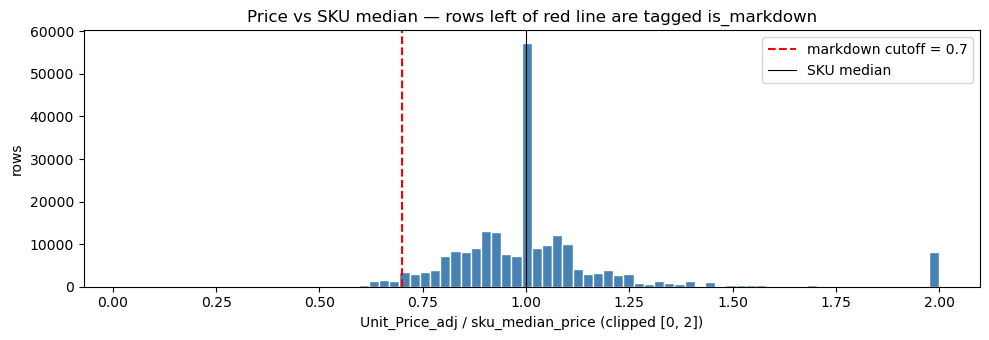


is_promo rows by brand:
brand
tiger balm     22035
ginger chew     7300
am gsg            86

--- LD.1 magnitude ---
is_lost_demand_week TRUE  : 55 (0.02% of all rows)
    of rows with non-NA flag : 0.03%

by brand (top):
brand
tiger balm    52
ferrero        2
am gsg         1

by DC:
DC
SF    52
NJ     3

by SKU (top 10):
ITEMNMBR
T-32206    52
A-61117     1
F-12418     1
F-20141     1

--- LD.2 timing cluster: T-32206 SF ---
T-32206 SF: 157 weeks, 52 flagged rows across 4 weeks
top 10 flagged weeks:
week_start  flagged  rows  low_stock  on_hand
2023-05-29       16    22         22  -1495.0
2023-06-19       13    28         28 -17450.0
2023-06-05       12    24         24  -5167.0
2023-06-12       11    24         24 -10034.0
2023-01-02        0    32          0 211757.0
2023-02-06        0    39          0 134105.0
2023-02-13        0    28          0 115794.0
2023-02-20        0    41          0 109769.0
2023-02-27        0    22          0  95642.0
2023-01-09        0    32      

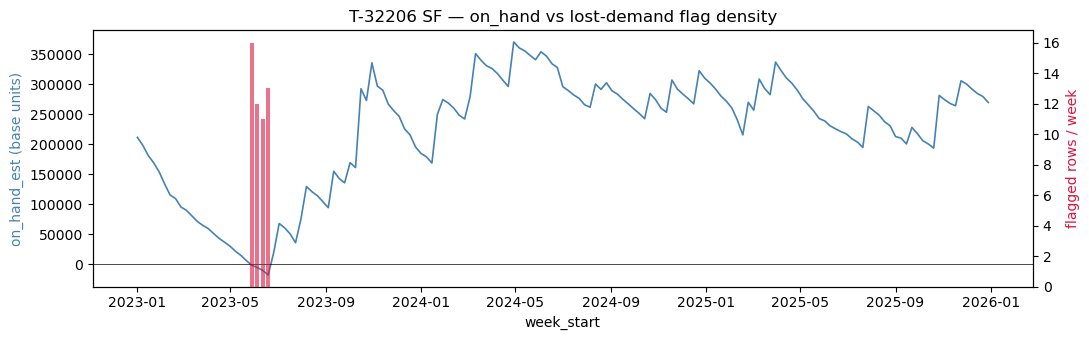


--- LD.3 DC substitution (flagged week -> other DC above cust median) ---


flagged (cust,sku,week) events : 26
   with another DC shipping same week  : 18
   that other DC shipped > cust median : 11
   substitution rate : 61.1%

--- LD.4 backfill signal (next order within 12w above cust median?) ---


flagged rows with next-order within 12w : 53
   next order > cust median : 9  (17.0%)
   baseline (cust_below_normal w/ no inv dip) : 29.1%  (n=42,529)

--- LD.5 spot check: T-32206 SF deepest-dip window ---
deepest week : 2023-06-19  (window ±4w)
week_start  rows  on_hand  typical  low_stock  lost_demand  cust_short
2023-05-22    37   6293.0   4211.0          0            0          22
2023-05-29    22  -1495.0   4211.0         22           16          16
2023-06-05    24  -5167.0   4211.0         24           12          12
2023-06-12    24 -10034.0   4211.0         24           11          11
2023-06-19    28 -17450.0   4211.0         28           13          13
2023-06-26    30  20000.0   4211.0          0            0          11
2023-07-03    24  68268.0   4211.0          0            0          11
2023-07-10    33  61031.0   4211.0          0            0           7
2023-07-17    33  51054.0   4211.0          0            0           6


In [4]:
# ---- Check 1: shape + no row loss ------------------------------------------
sales_in = pd.read_parquet(ART / 'sales_with_brand.parquet')
assert len(sales) == len(sales_in), f'Row count changed! {len(sales_in)} -> {len(sales)}'
print(f'row count preserved: {len(sales):,}')

# ---- Check 2: null sanity on the 4 flags -----------------------------------
print(f'is_promo nulls            : {sales["is_promo"].isna().sum()}')
print(f'is_markdown nulls         : {sales["is_markdown"].isna().sum()}')
print(f'is_stockout_week nulls    : {sales["is_stockout_week"].isna().sum():,}  (rows without inv_weekly coverage)')
print(f'is_lost_demand_week nulls : {sales["is_lost_demand_week"].isna().sum():,}  (no inv or no cust baseline)')

# ---- Check 3: markdown depth distribution ----------------------------------
md = sales[sales['is_markdown'] & sales['sku_median_price'].notna()].copy()
md['price_ratio'] = md['Unit_Price_adj'] / md['sku_median_price']
print(f'\nMarkdown depth (price / sku_median):')
print(md['price_ratio'].describe().to_string())

fig, ax = plt.subplots(figsize=(10, 3.5))
all_ratio = (sales.loc[sales['Unit_Price_adj'] > 0, 'Unit_Price_adj']
             / sales.loc[sales['Unit_Price_adj'] > 0, 'sku_median_price']).dropna()
ax.hist(all_ratio.clip(0, 2), bins=80, color='steelblue', edgecolor='white')
ax.axvline(MARKDOWN_FACTOR, color='red', linestyle='--',
           label=f'markdown cutoff = {MARKDOWN_FACTOR}')
ax.axvline(1.0, color='black', linestyle='-', lw=0.8, label='SKU median')
ax.set_xlabel('Unit_Price_adj / sku_median_price (clipped [0, 2])')
ax.set_ylabel('rows')
ax.set_title('Price vs SKU median — rows left of red line are tagged is_markdown')
ax.legend()
plt.tight_layout()
plt.show()

# ---- Check 4: is_promo brand mix -------------------------------------------
print('\nis_promo rows by brand:')
print(sales[sales['is_promo']].groupby('brand').size().sort_values(ascending=False).to_string())

# ===========================================================================
# Lost-demand validation (5 checks)
# ===========================================================================
ld = sales['is_lost_demand_week'] == True

# ---- LD.1: magnitude sanity overall + by brand + by DC ---------------------
print('\n--- LD.1 magnitude ---')
print(f'is_lost_demand_week TRUE  : {ld.sum():,} ({ld.mean()*100:.2f}% of all rows)')
den = (sales['is_lost_demand_week'].notna()).sum()
print(f'    of rows with non-NA flag : {ld.sum() / max(den,1) * 100:.2f}%')
print('\nby brand (top):')
print(sales[ld].groupby('brand').size().sort_values(ascending=False).head(10).to_string())
print('\nby DC:')
print(sales[ld].groupby('DC').size().sort_values(ascending=False).to_string())
print('\nby SKU (top 10):')
print(sales[ld].groupby('ITEMNMBR').size().sort_values(ascending=False).head(10).to_string())

# ---- LD.2: timing cluster for T-32206 SF -----------------------------------
# If the detector works, flagged-row density should spike in the weeks where
# week_on_hand is lowest. Plot weekly flagged count against weekly on_hand.
print('\n--- LD.2 timing cluster: T-32206 SF ---')
sku_t, dc_t = 'T-32206', 'SF'
sub = sales[(sales['ITEMNMBR'] == sku_t) & (sales['DC'] == dc_t)].copy()
wk = sub.groupby('week_start').agg(
    flagged=('is_lost_demand_week', lambda s: (s == True).sum()),
    rows=('is_lost_demand_week', 'size'),
    low_stock=('low_stock_week', lambda s: (s == True).sum()),
    on_hand=('week_on_hand', 'first'),
).reset_index()
print(f'{sku_t} {dc_t}: {len(wk)} weeks, {wk["flagged"].sum()} flagged rows across {int((wk["flagged"]>0).sum())} weeks')
print('top 10 flagged weeks:')
print(wk.sort_values('flagged', ascending=False).head(10).to_string(index=False))

fig, ax1 = plt.subplots(figsize=(11, 3.5))
ax1.plot(wk['week_start'], wk['on_hand'], color='steelblue', lw=1.2, label='on_hand_est')
ax1.axhline(0, color='black', lw=0.5)
ax1.set_ylabel('on_hand_est (base units)', color='steelblue')
ax1.set_xlabel('week_start')
ax2 = ax1.twinx()
ax2.bar(wk['week_start'], wk['flagged'], width=5, color='crimson', alpha=0.6,
        label='lost-demand rows')
ax2.set_ylabel('flagged rows / week', color='crimson')
ax1.set_title(f'{sku_t} {dc_t} — on_hand vs lost-demand flag density')
plt.tight_layout()
plt.show()

# ---- LD.3: DC substitution -------------------------------------------------
# When one DC is flagged for a (customer, SKU, week), do other DCs show
# above-normal shipments (customer sourced from a non-stocked-out DC)?
print('\n--- LD.3 DC substitution (flagged week -> other DC above cust median) ---')
flagged_keys = sales.loc[ld, ['CUSTNMBR', 'ITEMNMBR', 'week_start', 'DC']].copy()
if len(flagged_keys):
    merged = flagged_keys.merge(
        sales[['CUSTNMBR', 'ITEMNMBR', 'week_start', 'DC', 'QTY_BASE', 'cust_median_qty']],
        on=['CUSTNMBR', 'ITEMNMBR', 'week_start'], how='left', suffixes=('_flagged', '_any'),
    )
    other = merged[merged['DC_any'] != merged['DC_flagged']].copy()
    other['above_normal'] = (
        other['cust_median_qty'].notna()
        & (other['QTY_BASE'] > other['cust_median_qty'])
    )
    n_flag_events = flagged_keys.groupby(['CUSTNMBR', 'ITEMNMBR', 'week_start']).ngroups
    n_with_other  = other.groupby(['CUSTNMBR', 'ITEMNMBR', 'week_start']).ngroups
    n_substituted = (other.groupby(['CUSTNMBR', 'ITEMNMBR', 'week_start'])['above_normal']
                     .any().sum())
    print(f'flagged (cust,sku,week) events : {n_flag_events:,}')
    print(f'   with another DC shipping same week  : {n_with_other:,}')
    print(f'   that other DC shipped > cust median : {n_substituted:,}')
    if n_with_other:
        print(f'   substitution rate : {n_substituted / n_with_other * 100:.1f}%')
else:
    print('(no flagged rows)')

# ---- LD.4: backfill signal -------------------------------------------------
# If a customer was shorted, do they come back and order above-normal soon
# after? Look at same (cust, sku) next order within 12 weeks.
print('\n--- LD.4 backfill signal (next order within 12w above cust median?) ---')
sales = sales.sort_values(['CUSTNMBR', 'ITEMNMBR', 'DOCDATE']).reset_index(drop=True)
ld = sales['is_lost_demand_week'] == True  # recompute after re-sort
gb = sales.groupby(['CUSTNMBR', 'ITEMNMBR'])
sales['_next_qty']  = gb['QTY_BASE'].shift(-1)
sales['_next_date'] = gb['DOCDATE'].shift(-1)
sales['_days_to_next'] = (sales['_next_date'] - sales['DOCDATE']).dt.days
bf_mask = ld & sales['cust_median_qty'].notna() & sales['_days_to_next'].le(84)
bf = sales.loc[bf_mask].copy()
if len(bf):
    bf['next_above_normal'] = bf['_next_qty'] > bf['cust_median_qty']
    print(f'flagged rows with next-order within 12w : {len(bf):,}')
    print(f'   next order > cust median : {bf["next_above_normal"].sum():,}  ({bf["next_above_normal"].mean()*100:.1f}%)')
    # Baseline: cust_below_normal but NOT lost-demand (no inv dip)
    base_mask = ((~ld) & sales['cust_below_normal']
                 & sales['cust_median_qty'].notna()
                 & sales['_days_to_next'].le(84))
    base = sales.loc[base_mask]
    if len(base):
        base_rate = (base['_next_qty'] > base['cust_median_qty']).mean() * 100
        print(f'   baseline (cust_below_normal w/ no inv dip) : {base_rate:.1f}%  (n={len(base):,})')
else:
    print('(no flagged rows with a next-order window)')
sales = sales.drop(columns=['_next_qty', '_next_date', '_days_to_next'])

# ---- LD.5: spot-check the known-bad T-32206 SF window ----------------------
# Step 04 saw T-32206 SF min on_hand ~ -17,450. The weeks near that trough
# should be densely flagged (or at least have low_stock_week).
print('\n--- LD.5 spot check: T-32206 SF deepest-dip window ---')
sf = sales[(sales['ITEMNMBR'] == 'T-32206') & (sales['DC'] == 'SF')].copy()
if len(sf) and sf['week_on_hand'].notna().any():
    trough_week = sf.loc[sf['week_on_hand'].idxmin(), 'week_start']
    win_start = trough_week - pd.Timedelta(weeks=4)
    win_end   = trough_week + pd.Timedelta(weeks=4)
    w = sf[(sf['week_start'] >= win_start) & (sf['week_start'] <= win_end)]
    print(f'deepest week : {trough_week.date()}  (window ±4w)')
    summary = w.groupby('week_start').agg(
        rows=('QTY_BASE', 'size'),
        on_hand=('week_on_hand', 'first'),
        typical=('typical_weekly_base', 'first'),
        low_stock=('low_stock_week', lambda s: (s == True).sum()),
        lost_demand=('is_lost_demand_week', lambda s: (s == True).sum()),
        cust_short=('cust_below_normal', 'sum'),
    ).reset_index()
    print(summary.to_string(index=False))


## 5. Save downstream artifact

In [5]:
# Cast nullable-boolean flags to proper pandas 'boolean' dtype so parquet is happy.
for col in ('is_stockout_week', 'low_stock_week', 'is_lost_demand_week'):
    sales[col] = sales[col].astype('boolean')

sales.to_parquet(ART / 'sales_tagged.parquet')
print(f'sales_tagged  {sales.shape}  -> sales_tagged.parquet')
print(f'columns: {list(sales.columns)}')


sales_tagged  (236818, 41)  -> sales_tagged.parquet
columns: ['LOCNCODE', 'SLPRSNID', 'CUSTNMBR', 'CITY', 'STATE', 'ZIPCODE', 'SOP TYPE', 'SOPNUMBE', 'DOCDATE', 'ITEMNMBR', 'ITEMDESC', 'QUANTITY_adj', 'UOFM', 'QTYBSUOM', 'XTNDPRCE_adj', 'EXTDCOST_adj', 'Customer Type', 'Product Type', 'Source_File', 'Gross_Profit_adj', 'Margin_Pct_adj', 'UOM_Price', 'Unit_Price_adj', 'brand', 'sale_ym', 'DC', 'week_start', 'QTY_BASE', 'is_promo', 'sku_median_price', 'markdown_threshold', 'is_markdown', 'week_on_hand', 'inv_confidence', 'is_stockout_week', 'typical_weekly_base', 'low_stock_week', 'cust_median_qty', 'cust_below_normal', 'is_lost_demand_week', 'is_clean_demand']


## 6. Promote

Once validation above looks right, extract the core logic into `src/tagging.py` and replace the inline code here with `from src.<module> import ...`. Downstream dev notebooks can then import the same function.